   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 5.8 MB/s eta 0:00:00
Router-0: processed=90 congested_steps=10 rerouted_in=5
Router-1: processed=92 congested_steps=11 rerouted_in=12
Router-2: processed=63 congested_steps=9 rerouted_in=16
Router-3: processed=61 congested_steps=10 rerouted_in=19

Total sent: 306, Total rerouted: 52 (17.0%)


<Axes: title={'center': 'Congestion & Rerouting Over Time'}>

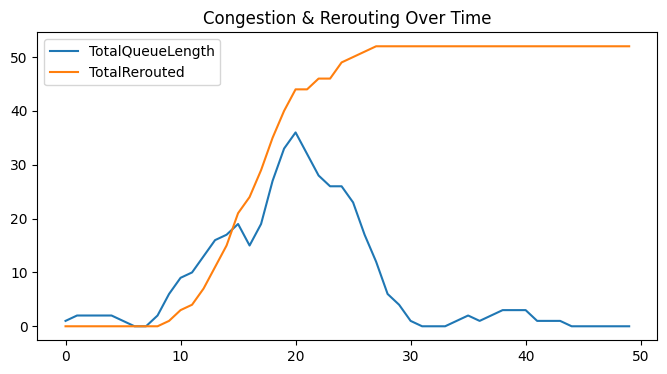

In [1]:
!pip install mesa -q

import random
import mesa
import pandas as pd

random.seed(7)

# Simulation settings
NUM_ROUTERS = 4
NUM_USERS = 10
CONGESTION_THRESHOLD = 4
PACKET_SEND_PROB = 0.45
BURST_STEPS = range(10, 22)
BURST_EXTRA_PACKETS = 2
STEPS = 50


# Router agent that handles packet processing
class RouterAgent(mesa.Agent):
    def __init__(self, model, capacity_per_step=2):
        super().__init__(model)
        self.queue = []
        self.capacity_per_step = capacity_per_step
        self.processed_count = 0
        self.congested_steps = 0
        self.rerouted_in = 0

    # Check if the router has too many packets waiting
    @property
    def is_congested(self):
        return len(self.queue) > CONGESTION_THRESHOLD

    # Add a packet to the router queue
    def receive_packet(self, packet):
        self.queue.append(packet)

    # Process packets during each simulation step
    def step(self):
        for _ in range(min(self.capacity_per_step, len(self.queue))):
            self.queue.pop(0)
            self.processed_count += 1

        if self.is_congested:
            self.congested_steps += 1


# User agent that generates network traffic
class UserAgent(mesa.Agent):
    def __init__(self, model, home_router):
        super().__init__(model)
        self.home_router = home_router
        self.packets_sent = 0
        self.packets_rerouted = 0

    # Send packets and reroute when a router is congested
    def step(self):
        num_packets = 0

        # Normal packet sending
        if random.random() < PACKET_SEND_PROB:
            num_packets = 1

        # Create extra traffic during burst periods
        if self.model.steps in BURST_STEPS and random.random() < PACKET_SEND_PROB:
            num_packets += random.randint(1, BURST_EXTRA_PACKETS)

        for _ in range(num_packets):
            target_router = self.home_router

            # Find another router if the current one is congested
            if target_router.is_congested:
                peers = [r for r in self.model.routers if r is not target_router]
                alternate = min(peers, key=lambda r: len(r.queue))

                if len(alternate.queue) < len(target_router.queue):
                    target_router = alternate
                    alternate.rerouted_in += 1
                    self.packets_rerouted += 1

            packet = {"sender": self.unique_id}
            target_router.receive_packet(packet)
            self.packets_sent += 1


# Main network simulation model
class NetworkModel(mesa.Model):
    def __init__(self, num_routers=NUM_ROUTERS, num_users=NUM_USERS, rng=None):
        super().__init__(rng=rng)

        # Create routers
        self.routers = [
            RouterAgent(self, capacity_per_step=2)
            for _ in range(num_routers)
        ]

        # Assign users to routers
        self.users = [
            UserAgent(self, home_router=self.routers[i % num_routers])
            for i in range(num_users)
        ]

        # Collect simulation data
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "TotalQueueLength": lambda m: sum(len(r.queue) for r in m.routers),
                "CongestedRouters": lambda m: sum(1 for r in m.routers if r.is_congested),
                "TotalRerouted": lambda m: sum(u.packets_rerouted for u in m.users),
            }
        )

    # Run one step of the simulation
    def step(self):
        for user in self.users:
            user.step()

        for router in self.routers:
            router.step()

        self.datacollector.collect(self)


# Create and run the simulation
model = NetworkModel(rng=7)

for _ in range(STEPS):
    model.step()


# Display router results
df = model.datacollector.get_model_vars_dataframe()

for i, router in enumerate(model.routers):
    print(
        f"Router-{i}: processed={router.processed_count} "
        f"congested_steps={router.congested_steps} "
        f"rerouted_in={router.rerouted_in}"
    )


# Display overall network results
total_sent = sum(u.packets_sent for u in model.users)
total_rerouted = sum(u.packets_rerouted for u in model.users)

print(
    f"\nTotal sent: {total_sent}, "
    f"Total rerouted: {total_rerouted} "
    f"({100 * total_rerouted / total_sent:.1f}%)"
)


# Plot congestion and rerouting results over time
df.plot(
    y=["TotalQueueLength", "TotalRerouted"],
    figsize=(8, 4),
    title="Congestion & Rerouting Over Time"
)